# Titanic Decision Tree

## Decision Trees

Decision Trees (DTs) are a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. A tree can be seen as a piecewise constant approximation.

For instance, in the example below, decision trees learn from data to approximate a sine curve with a set of if-then-else decision rules. The deeper the tree, the more complex the decision rules and the fitter the model.

![Decision Trees](https://scikit-learn.org/stable/_images/sphx_glr_plot_tree_regression_001.png)

### Some advantages of decision trees are:

* Simple to understand and to interpret. Trees can be visualised.

* Requires little data preparation. Other techniques often require data normalisation, dummy variables need to be created and blank values to be removed. Note however that this module does not support missing values.

* The cost of using the tree (i.e., predicting data) is logarithmic in the number of data points used to train the tree.

* Able to handle both numerical and categorical data. However scikit-learn implementation does not support categorical variables for now. Other techniques are usually specialised in analysing datasets that have only one type of variable. See algorithms for more information.

* Able to handle multi-output problems.

* Uses a white box model. If a given situation is observable in a model, the explanation for the condition is easily explained by boolean logic. By contrast, in a black box model (e.g., in an artificial neural network), results may be more difficult to interpret.

* Possible to validate a model using statistical tests. That makes it possible to account for the reliability of the model.

* Performs well even if its assumptions are somewhat violated by the true model from which the data were generated.

([Read more about decision trees here](https://scikit-learn.org/stable/modules/tree.html))

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Import Dataset

In [3]:
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')
submission = pd.read_csv('../input/titanic/gender_submission.csv')
test['Survived']= submission['Survived']

# Combine Train and Test Datasets for Data Cleaning
df = pd.concat([test.assign(ind="test"), train.assign(ind="train")])

# Data Overview

In [4]:
df.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,ind
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,test
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1,test


In [5]:
[train.shape , test.shape , submission.shape]

[(891, 12), (418, 12), (418, 2)]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
 11  Survived     1309 non-null   int64  
 12  ind          1309 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 143.2+ KB


<AxesSubplot:xlabel='Sex', ylabel='Survived'>

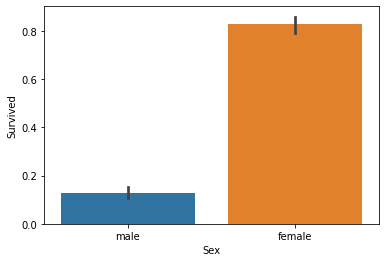

In [7]:
sns.barplot(data=df, x='Sex', y= 'Survived')

<AxesSubplot:xlabel='Survived', ylabel='count'>

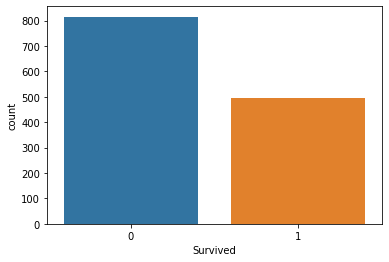

In [8]:
sns.countplot(data=df, x='Survived')

<AxesSubplot:xlabel='Age', ylabel='Fare'>

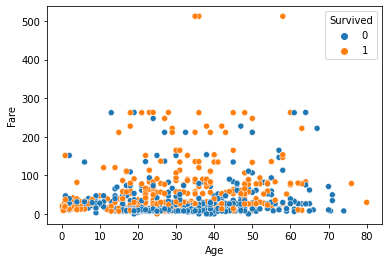

In [9]:
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')

# EDA

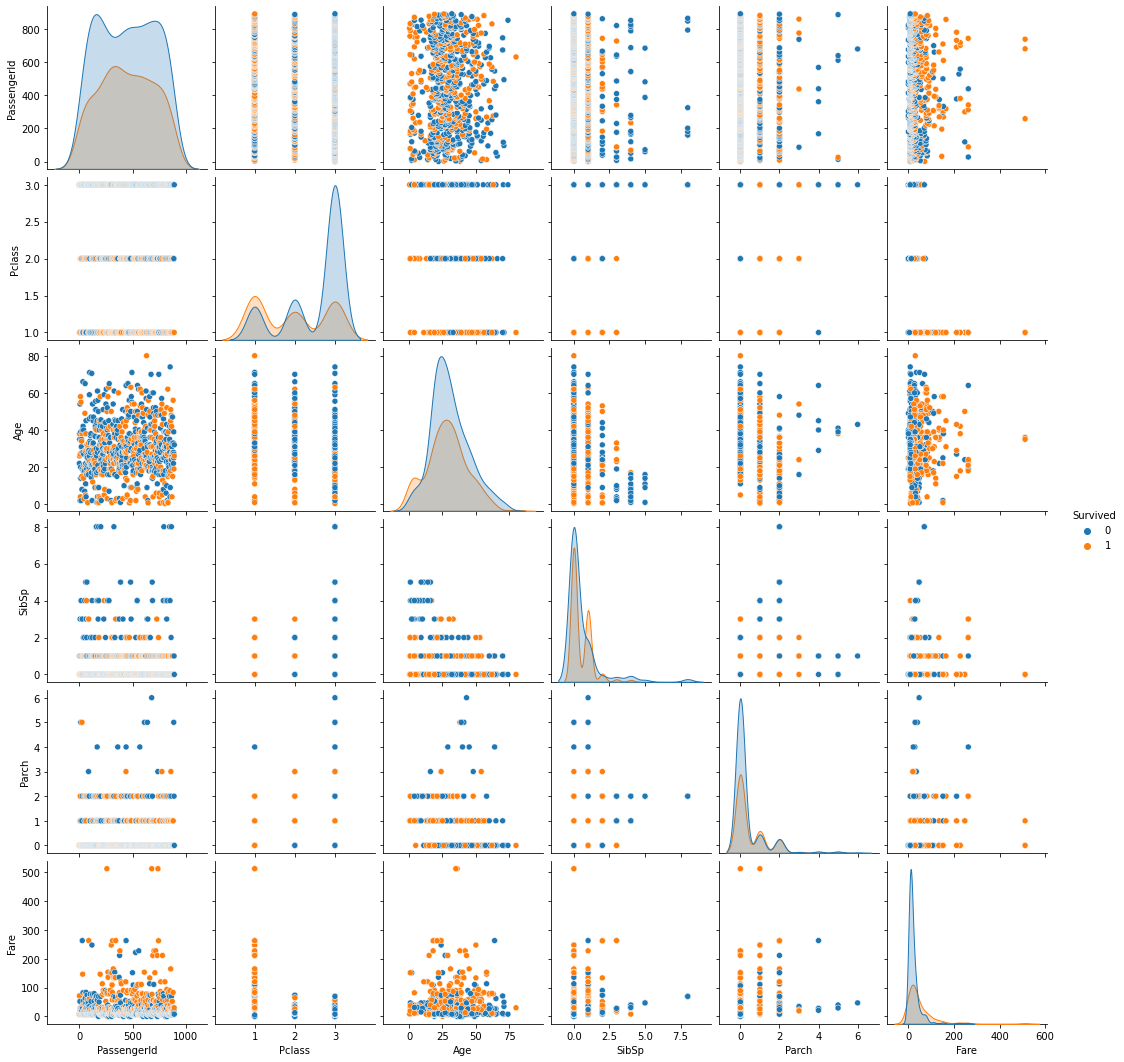

In [12]:
sns.pairplot(data = train,hue='Survived')

# Data Cleaning
I did this part with details on [this notebook](https://www.kaggle.com/sajjadnajafi/logistic-regression-titanic/).

In [13]:
# Deal with "Cabin" Column
df = df.drop(['Cabin'] , axis=1)

# Some columns have no effect on survival so we remove them:
df = df.drop(['PassengerId'] , axis=1)
df = df.drop(['Ticket'] , axis=1)
df = df.drop(['Name'] , axis=1)

# Deal with "Age" Column
df = df.dropna(axis=0, subset=['Age'])

# We have some null in Embarked and Fare columns:
df = df.dropna(axis=0, subset=['Embarked'])
df = df.dropna(axis=0, subset=['Fare'])

# Dealing with Categorical Data
df['Pclass'] = df['Pclass'].apply(str)

# Convert All Object type to One hot encoding

# START ONE HOT ENCODING
df_num = df.select_dtypes(exclude='object')
df_obj = df.select_dtypes(include='object')
non_dummy_cols = ['ind']
dummy_cols = list(set(df_obj.columns) - set(non_dummy_cols))
df_obj = pd.get_dummies(df_obj, columns=dummy_cols, drop_first=True)
df = pd.concat([df_num, df_obj], axis = 1)
# END ONE HOT ENCODING

# Split Test data from df
test, train = df[df["ind"].eq("test")], df[df["ind"].eq("train")]

# We should Drop indicator Column from test and train dataframes:
test= test.drop(['ind'], axis=1)
train= train.drop(['ind'], axis=1)

# Determine the Features & Target Variable

In [14]:
# Split the Data to Train & Test
X_test, y_test = test.drop(columns='Survived').copy(), test['Survived'].copy()
X_train, y_train = train.drop(columns='Survived').copy(), train['Survived'].copy()

# Train the Model

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
model = DecisionTreeClassifier()

In [17]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

# Predicting Test Data

In [18]:
y_pred = model.predict(X_test)

# Evaluating the Model

In [19]:
from sklearn.metrics import confusion_matrix,classification_report

In [20]:
confusion_matrix(y_test,y_pred)

array([[159,  45],
       [ 33,  94]])

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       204
           1       0.68      0.74      0.71       127

    accuracy                           0.76       331
   macro avg       0.75      0.76      0.75       331
weighted avg       0.77      0.76      0.77       331



In [22]:
model.feature_importances_

array([0.26550872, 0.05920604, 0.01474663, 0.22631752, 0.01514444,
       0.08640499, 0.29736009, 0.00705426, 0.02825732])

In [24]:
pd.DataFrame(index=X_train.columns,data=model.feature_importances_,columns=['Feature Importance'])

,Feature Importance
Age,0.265509
SibSp,0.059206
Parch,0.014747
Fare,0.226318
Pclass_2,0.015144
Pclass_3,0.086405
Sex_male,0.297360
Embarked_Q,0.007054
Embarked_S,0.028257


# Reporting Model Results

In [39]:
def report_model(model):
    model_preds = model.predict(X_test)
    print(classification_report(y_test,model_preds))
    print('\n')
    plt.figure(figsize=(12,8),dpi=72)
    plot_tree(model,filled=True,feature_names=X_train.columns);

In [40]:
pruned_tree = DecisionTreeClassifier(max_depth=2)
pruned_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2)

              precision    recall  f1-score   support

           0       0.80      0.96      0.87       204
           1       0.91      0.61      0.73       127

    accuracy                           0.82       331
   macro avg       0.85      0.78      0.80       331
weighted avg       0.84      0.82      0.82       331





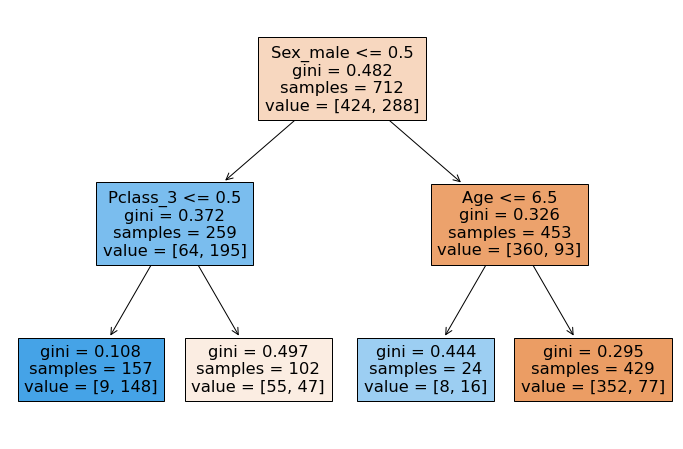

In [41]:
report_model(pruned_tree)

# Max Leaf Nodes

In [42]:
pruned_tree = DecisionTreeClassifier(max_leaf_nodes=3)
pruned_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_leaf_nodes=3)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89       204
           1       1.00      0.61      0.75       127

    accuracy                           0.85       331
   macro avg       0.90      0.80      0.82       331
weighted avg       0.88      0.85      0.84       331





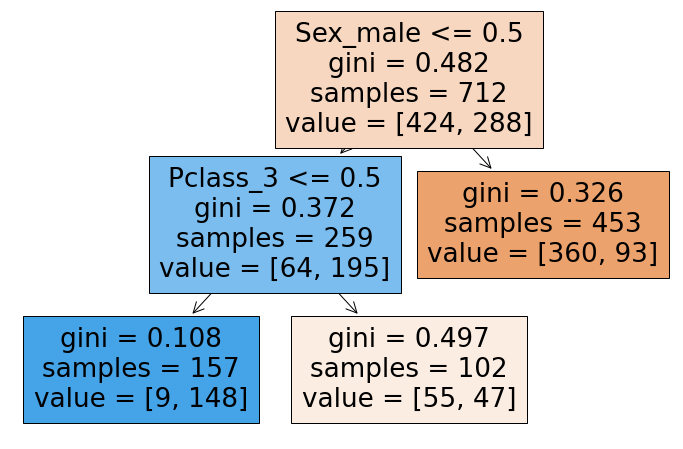

In [43]:
report_model(pruned_tree)